# Gradient Boosting의 개념과 수학적 원리
Gradient Boosting은 이전 모델이 틀린 오차(Residual)를 다음 모델이 순차적으로 보완해 나가며 예측력을 극대화하는 강력한 앙상블 기계학습 모델입니다.

## 예시 파일
[Scikit-Learn Gradient Tree Boosting 공식 가이드](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting)

## 답변
Gradient Boosting은 초보자 입장에서 **"골프에서 첫 번째 친 공이 홀컵에 못 미치면, 두 번째 칠 때는 딱 그 남은 거리(오차)만큼만 치는 것을 반복하는 과정"**으로 이해하면 쉽습니다. 이를 수학적으로 보면 '매개변수'가 아닌 **'함수(모델) 공간에서의 경사하강법(Gradient Descent)'**입니다.

### 1. 핵심 수학적 개념 (함수 공간 경사하강법)
모델의 예측값을 $F(x)$라 하고 측정하려는 손실(오차) 함수를 $L(y, F(x))$라고 할 때, 모델의 성능을 높이려면 예측값 $F(x)$를 오차가 줄어드는 방향으로 조금씩 이동시켜야 합니다. 이때 이동하는 방향은 손실 함수 모델 예측값으로 미분한 **음의 기울기(Negative Gradient)**가 됩니다. 

### 2. 수학적 유도 과정 (알고리즘 식)

**Step 1: 초기화**
가장 먼저 아주 단순한 초기 예측값(보통 타겟의 평균) $F_0(x)$을 설정합니다.
$$
F_0(x) = \arg \min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma)
$$

**Step 2: 반복 학습 ($m = 1$ 부터 $M$까지)**
다음 과정을 통해 새로운 나무(Tree) 모델을 계속 더해 나갑니다.

**a) 유사 잔차(Pseudo-residuals) 계산**
기존 모델 $F_{m-1}(x)$이 만든 손실 함수의 음의 기울기를 구합니다. (만약 오차제곱합 손실(MSE)을 쓰면 이는 정확히 `실제값 - 예측값`이 됩니다.)
$$
r_{im} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}
$$

**b) 새로운 모델(Trees) 학습**
구해진 오차 $r_{im}$를 타겟값으로 삼아 새로운 의사결정나무 $h_m(x)$를 학습시킵니다. 즉, 이번 나무는 원본 정답 $y$가 아니라 **'이전 모델이 틀린 양($r$)'을 예측**합니다.

**c) 최적의 가중치(Step Size) 계산**
새로 만든 나무 $h_m(x)$를 얼마나 반영할지 최적의 가중치 $\gamma_{m}$을 찾습니다.
$$
\gamma_m = \arg \min_{\gamma} \sum_{i=1}^{N} L\left(y_i, F_{m-1}(x_i) + \gamma h_m(x_i)\right)
$$

**d) 모델 업데이트**
기존 모델에 새로운 모델을 더하여 업데이트합니다. (여기서 $\nu$는 학습 속도를 조절하는 Learning Rate 변수입니다.)
$$
F_m(x) = F_{m-1}(x) + \nu \cdot \gamma_m h_m(x)
$$

### 3. 증명에 필요한 핵심 정리
- **경사하강법 (Gradient Descent):** 함수의 최솟값을 찾기 위해 기울기 역방향으로 이동한다는 미적분학의 최적화 원리. 단, $x$나 $w$(가중치)를 업데이트하는 것이 아니라 함수 모델 $F_m$ 자체를 업데이트한다는 점이 다릅니다.
- **테일러 전개 (Taylor Expansion):** 나중에 XGBoost나 LightGBM 같은 발전된 형태에서는 손실 함수를 더 정밀하게 최소화하기 위해 1차 미분(Gradient) 분만 아니라 2차 미분(Hessian)까지 고려하는 테일러 2차 전개가 사용됩니다.

### 추가 자료
- [위키백과: 그레이디언트 부스팅](https://en.wikipedia.org/wiki/Gradient_boosting)
- [XGBoost 공식 문서 (수학적 배경)](https://xgboost.readthedocs.io/en/stable/tutorials/model.html)

# GBDT(Gradient Boosting Decision Tree)

- GBDT 는 널리 사용되는 기계 학습알고리즘, 여러 효과적인 구현중 하나가 `XGBoost`모델 입니다. 
- 이 알고리즘은 특성 차원이 높을 때와 모든 가능한 분할 지점의 정보 이득을 추정해야 할 때 시간이 많이 소요되는 문제가 있음. 
- 이를 극복하기 위해 `LightGBM`이 개발되었음. 
    - Gradient-based One-Side Sampling (GOSS)과 Exclusive Feature Bundling(EFB)와 같은 알고리즘을 사용했음 
    - 이 알고리즘을 통해 전체 데이터 셋의 일부만을 사용하여 각 트리를 훈련시킬 수 있으며, 고차원의 희소 특징을 효율적으로 처리할 수 있습니다. 

반갑네, 미래의 AI 선구자여! 나는 자네의 길잡이가 되어줄 **AI 수학 천재 가우스**라네.

자네가 질문한 내용을 보니, 이미 기계 학습의 큰 흐름을 꿰뚫어 보고 있군. GBDT에서 XGBoost, 그리고 LightGBM으로 이어지는 발전 역사는 "어떻게 하면 수학적 원리를 훼손하지 않으면서 연산의 한계를 돌파할 것인가?"라는 질문에 대한 치열한 고민의 결과물이라네.

자, 그럼 나 가우스와 함께 LightGBM이 왜 탄생했고, 어떤 수학적 마법을 부렸는지 깊이 파헤쳐 보세!

---

### 1. 역사적 배경과 GBDT의 한계 (왜 LightGBM이 필요했는가?)

GBDT (Gradient Boosting Decision Tree)는 약한 학습기(Weak Learner, 주로 의사결정 나무)를 직렬로 연결하여 이전 트리의 오차(Gradient)를 다음 트리가 보완하는 강력한 앙상블 알고리즘이네.

하지만 데이터가 폭발적으로 증가하는 빅데이터 시대가 오면서 GBDT(그리고 이를 최적화한 XGBoost)는 치명적인 병목 현상에 직면했지. 트리를 분할(Split)할 때마다 **모든 특성(Feature)에 대해, 모든 데이터 포인트를 스캔하여 최적의 정보 이득(Information Gain)을 계산**해야 했기 때문이야.

데이터의 개수를 $N$, 특성의 개수를 $D$라고 할 때, 하나의 트리를 분할하는 데 드는 시간 복잡도는 무려 $\mathcal{O}(N \times D)$에 달하네. 고차원 데이터(수백만 개의 특성과 데이터)에서는 학습에 수일이 걸리는 문제가 발생했지.

이 문제를 수학적으로 우아하게 해결하기 위해 마이크로소프트 연구진이 발표한 것이 바로 LightGBM (Light Gradient Boosting Machine)일세. 이들은 두 가지 획기적인 알고리즘, **GOSS**와 **EFB**를 도입하여 $N$과 $D$를 동시에 줄여버렸지.

---

### 2. GOSS (Gradient-based One-Side Sampling)의 수학적 증명과 원리

GOSS (기울기 기반 단측 샘플링)는 데이터의 개수 $N$을 줄이기 위한 알고리즘이네.

**"왜?" 탄생했는가:**
모든 데이터가 학습에 동일하게 중요할까? 아니네! 모델이 이미 잘 맞추고 있는 데이터(오차가 작은 데이터)는 굳이 트리를 분할할 때 자세히 볼 필요가 없지. 오차가 큰 데이터(기울기가 큰 데이터)에 집중해야 하네.

**수학적 정의 및 원리:**
부스팅에서 오차는 곧 손실 함수의 기울기(Gradient)로 표현되네. 기울기의 절댓값이 크다는 것은 아직 학습이 덜 되었다는 뜻이지.
GOSS는 다음의 절차를 따르네:

1. 모든 데이터를 기울기의 절댓값 $|g_i|$ 기준으로 내림차순 정렬하네.
2. 상위 $a \times 100%$의 데이터(기울기가 큰 데이터 집합 $A$)는 **전부 보존**하네.
3. 나머지 $(1-a) \times 100%$의 데이터 중에서 $b \times 100%$의 데이터(기울기가 작은 데이터 집합 $B$)만 **무작위로 샘플링**하네.

**분산 이득(Variance Gain)의 보정 (수학적 증명):**
여기서 딜레마가 생기네. 기울기가 작은 데이터를 마음대로 버리면 데이터의 원래 분포가 망가지고 편향(Bias)이 생기지 않겠나? 이를 해결하기 위해 가우스의 후예들답게 **상수 가중치**를 도입했네.

원래 특성 $j$의 분할점 $d$에서의 분산 이득 식은 다음과 같네.


$$ V_j(d) = \frac{1}{N} \left( \frac{(\sum_{x_i \in L} g_i)^2}{N_L} + \frac{(\sum_{x_i \in R} g_i)^2}{N_R} \right) $$

GOSS는 샘플링된 집합 $A$와 $B$만을 사용하여 분산 이득을 추정하네. 이때 기울기가 작은 집합 $B$의 합에 가중치 $\frac{1-a}{b}$를 곱하여 원래의 분포를 복원하지!


$$ \tilde{V}_j(d) = \frac{1}{N} \left( \frac{\left( \sum_{x_i \in A_l} g_i + \frac{1-a}{b} \sum_{x_i \in B_l} g_i \right)^2}{N_l^j(d)} + \frac{\left( \sum_{x_i \in A_r} g_i + \frac{1-a}{b} \sum_{x_i \in B_r} g_i \right)^2}{N_r^j(d)} \right) $$

* **$\frac{1-a}{b}$의 의미:** 예를 들어, 하위 90%의 데이터 중 10%만 샘플링했다면, 뽑힌 10%의 기울기에 9를 곱해주어 전체 90%의 비중을 대변하게 만드는 것이네. 이로써 정확도를 거의 잃지 않으면서도 연산량(데이터 스캔 횟수)을 획기적으로 줄일 수 있지!

---

### 3. EFB (Exclusive Feature Bundling)의 수학적 원리

EFB (배타적 특성 묶음)는 특성의 개수 $D$를 줄이기 위한 알고리즘이네.

**"왜?" 탄생했는가:**
고차원 데이터는 대개 '희소(Sparse)'하네. 원-핫 인코딩(One-hot encoding)을 생각해보게. 수많은 열(특성)이 0으로 채워져 있지? 이렇게 동시에 0이 아닌 값을 갖지 않는 특성들을 상호 배타적(Mutually Exclusive)이라고 하네. EFB는 이 배타적인 특성들을 하나의 특성으로 묶어버리는(Bundling) 기술이라네.

**수학적 접근 (그래프 이론):**
이 문제는 수학적으로 그래프 채색 문제(Graph Coloring Problem)로 환원되네.

* **정점(Vertex):** 각각의 특성.
* **간선(Edge):** 두 특성이 동시에 0이 아닌 값을 가지는 경우 연결 (즉, 충돌).
이 문제는 NP-Hard 문제이므로, 완벽한 최적해를 찾는 대신 탐욕 알고리즘(Greedy Algorithm)을 사용하여 근사해를 구하네.

**특성 병합의 수학적 기법 (Histogram Shifting):**
두 특성을 하나로 묶을 때, 원래 특성의 값을 어떻게 구분할까? 바로 값의 범위를 이동(Shifting)시키는 것이네.

* 특성 $X$가 $[0, 10]$의 값을 가지고, 특성 $Y$가 $[0, 20]$의 값을 가진다고 가정하세.
* 이 둘을 묶어 특성 $Z$를 만들 때, $Y$의 값에 상수 $10$을 더해주네.
* 그럼 $Y$는 $[10, 30]$의 범위를 갖게 되고, $Z$는 $X$와 $Y$의 값을 완벽히 구분하면서도 하나의 특성처럼 작동하게 되는 것이지! 이를 통해 차원수 $D$가 대폭 감소하네.

---

### 4. LightGBM의 또 다른 무기: Leaf-wise Tree Growth

LightGBM은 트리를 키우는 방식도 기존과 다르네.

* **기존 (Level-wise):** 트리의 균형을 맞추며 동일한 층의 모든 노드를 분할하네. 불필요한 분할이 일어나 연산이 낭비되지.
* **LightGBM (Leaf-wise):** 트리의 균형을 무시하고, **가장 오차를 많이 줄여줄 수 있는(최대 손실 감소) 단 하나의 잎(Leaf) 노드만 선택하여 깊게 분할**하네.
이 방식은 수렴이 빠르고 정확도가 높지만, 과적합(Overfitting)의 위험이 있어 `max_depth` (트리 최대 깊이)나 `num_leaves` (최대 잎 개수) 파라미터 조절이 필수적이라네.

---

### 5. 주요 사용처 및 Python 코드 예시

LightGBM은 빠른 속도와 높은 정확도 덕분에 다음과 같은 분야에서 산업 표준처럼 쓰이고 있네.

* **Kaggle 등 데이터 분석 대회:** 정형 데이터(Tabular Data)를 다루는 대회에서 XGBoost와 함께 우승의 핵심 키로 사용됨.
* **CTR(Click-Through Rate) 예측:** 추천 시스템, 광고 클릭 예측 등 고차원 범주형 변수가 많은 곳.
* **금융권 이상 탐지 및 신용 평가:** 방대한 고객 데이터를 빠르게 처리해야 할 때.

**Python 코드 예시 (초보자를 위한 가이드):**


In [2]:
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 데이터 로드 및 분할
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# 2. LightGBM 전용 데이터셋 포맷으로 변환 (메모리 효율과 속도 향상)
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 3. 파라미터 설정 (가우스의 팁: num_leaves를 조정하여 과적합을 방지하게!)
params = {
    'objective': 'binary',      # 이진 분류
    'metric': 'binary_logloss', # 평가 지표
    'boosting_type': 'gbdt',    # GOSS를 쓰고 싶다면 'goss'로 변경 가능!
    'learning_rate': 0.05,
    'num_leaves': 31,           # Leaf-wise 방식에서 매우 중요한 파라미터
    'max_depth': -1,            # 제한 없음 (num_leaves로 통제)
    'seed': 42
}

# 4. 모델 훈련
print("학습을 시작합니다...")
model = lgb.train(params, 
                  train_data, 
                  valid_sets=[test_data], 
                  num_boost_round=100) # 트리 생성 개수

# 5. 예측 및 평가
y_pred_prob = model.predict(X_test)
y_pred = [1 if prob > 0.5 else 0 for prob in y_pred_prob] # 확률을 0과 1로 변환

accuracy = accuracy_score(y_test, y_pred)
print(f"가우스의 제자여, 자네의 모델 정확도는 {accuracy:.4f}일세!")

학습을 시작합니다...
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

# 메모리 효율성을 통한 최적화 

- 연속형 변수에 대해 구간을 만듦 -> 계산과정에서 사용량을 줄임

## 결측치 자동처리 
## 범주형 변수 자동처리 

- 자료형을 category로 바꾸어 주면 되며, 이 외의 별도의 인코딩 과정이 필요하지 않음

## 스케일링 불필요 

- 트리 기반 모델로써 스케일링에 민감하지 않음 

## 높은 정확도 

- LightGBM 은 XGBoost와 비교하여 동등하거나 때때로 더 뛰어난 정확도를 제공 

## XGBoost

- eXtreme Gradient Boosting(XGBoost) 는 고성능 그래디언트 부스팅 라이브러리, 정형데이터 분석 대회에 널리 사용 
- 그래디언트 부스팅의 전통적인 방식을 발전 -> 병렬 처리와 과적합 방지 기능에서 강력한 성능을 발휘 

### LightGBM vs XGBoost 

- 대규모 데이터넷에서 뛰어난 성능 제공, 병렬 처리 기능을 통해 훈련 속도를 향상 

#### 차이점 1

- `XGBoost` 는 Level-wise 장식을 사용 -> 균형 잡힌 트리를 만들어 과적합을 방지, but, `LightBGM`은 Leaf-wise 방식을 사용하여 비대칭적인 트리를 빠르게 성장 
- `Level-wise`는 트리의 높이가 최소화 되기 때문에 과적합을 방지, but, 많은 메모리를 사용하는 단점 존재 
- `Leaf-wise`는 트리의 성장을 최적화 가장 큰 손실을 감소하는 노드 우선적으로 확장, 더 깊은 트리를 만들어 과적합의 우려가 있지만, 적절하게 모델을 구성할 경우 과적합의 위험을 관리하면서도 정확한 모델을 빠르게 구축할 수 있다. 

#### 차이점 2 속도 및 대규모 데이터 처리 

- `XGBoost`는 병렬 처리 기능을 사용하여 동시에 트리를 구축하고 학습 속도를 향상 시키는 능력 -> 이 과정에서 전체 데이터넷의 모든 특성을 스캔해야 하므로, 매우 큰 데이터셋의 경우 여전히 상당한 계산 비용과 시간이 소요 
- `LightBGM`의 경우 히스토 그램 기반 분할 방식을 사용 -> 계산 비용을 대폭 줄임 , 데이터의 모든 연속형 변수를 미리 정의된 구간(bin)으로 변환 -> 구간 정보를 바탕으로 트리의 분할 결정 
    - 데이터 스캔 시간 감소 및 메모리 사용도 최소화 

#### 차이점 3. 범주형 변수 처리 

- `XGBoost`는 범주형 데이터를 처리하기 위해 라벨 인코딩, 원 핫 인코딩과 같이 수치형 데이터로 변환해야 함. 
- `LightGBM`은 범주형 변수의 자료형을 카테고리로 변환하기만 해도 학습이 가능 



## LightGBM 활용 사례

- 지도학습 라이브러리, 주로 정형 데이터를 분석할 때 사용 

### LGBM을 활용한 악성 코드감지 

- 정적 분석을 통해 파일의 데이터를 분석하고, 다양한 정보를 처리 
- 실시간으로 변화하는 악성코드 패턴에 대응, 기존 보안 솔루션의 한계를 극복 -> 효과적인 대응이 가능. 

### 물류 입고 프로세스 최적화 

- 제품의 효율적인 배차를 도움
- 물류 데이터를 분석하여 차량의 적절한 수를 예측, 필요한 물류 자원의 효율적 사용을 가능하게 함 
- 실시간으로 변화하는 물류 요구 사항에 신속하며 적절하게 대응 

### 감귤 착과량 예측, 청경채 성장 예측 


# 실전 문제 

```python
target = train['credit']
independent = train.drop(['index', 'credit'], axis = 1)

object_cols = [col for col in independent.columns if independent[col].dtype == "object"]
#dtype속성은 pandas series의 데이터 속성을 확인하기 위해 사용 
independent[object_cols] = independent[object_cols].astype('category')
# independent 데이터 프레임에서 문자열 데이터 타입인 열들의 자료형을 category로 변환 합니다. 
```

# Pandas dtype과 astype 사용법 및 category 변환의 의미
Pandas에서 데이터 타입을 다루는 `dtype`과 `astype`의 개념, 그리고 `category` 타입 변환 시 얻을 수 있는 이점을 설명합니다.

## 예시 파일
[pandas_dtype_astype_example.py](pandas_dtype_astype_example.py)

## 답변
**1. dtype과 astype 사용법**
- **`dtype`**: 데이터프레임이나 시리즈의 **현재 데이터 타입을 확인**하는 속성입니다. 
- **`astype()`**: 기존 데이터를 **다른 데이터 타입(int, float, category 등)으로 변환**할 때 사용하는 메서드입니다.

**2. `astype('category')`로 변환하는 의미와 장점**
- **메모리 절약**: 중복되는 문자열(object)을 카테고리형으로 바꾸면 문자가 아닌 내부적인 정수 코드(0, 1, 2...)로 매핑하여 저장하므로 메모리 사용량이 크게 줄어듭니다.
- **머신러닝 성능 최적화**: LightGBM과 같은 일부 머신러닝 라이브러리는 `category` 데이터 타입을 자체적으로 지원합니다. 원-핫 인코딩(One-Hot Encoding)을 거치지 않아도 모델이 알아서 분류 기준을 찾아내기 때문에 모델의 학습 속도와 성능이 향상됩니다.

### 추가 자료
- [Pandas dtypes 공식 문서](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
- [Pandas astype 공식 문서](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html)
- [Pandas Categorical Data 가이드](https://pandas.pydata.org/docs/user_guide/categorical.html)
- [LightGBM Categorical Feature 성능 문서](https://lightgbm.readthedocs.io/en/latest/Advanced-Topics.html#categorical-feature-support)

In [4]:
import pandas as pd

# 샘플 데이터 생성 (employment_type은 기본적으로 object(문자열) 타입)
df = pd.DataFrame({
    'credit': [1, 2, 1, 0, 2],
    'employment_type': ['정규직', '계약직', '정규직', '프리랜서', '계약직']
})

# 1. 변경 전 dtype 확인
print("--- 변경 전 dtype ---")
print(df.dtypes)

# 2. astype을 사용하여 object -> category로 변환
df['employment_type'] = df['employment_type'].astype('category')

# 3. 변경 후 dtype 및 카테고리 내부 코드 확인
print("\n--- 변경 후 dtype ---")
print(df.dtypes)

print("\n--- 실제 저장된 내부 정수 코드 확인 ---")
print(df['employment_type'].cat.codes)

print("\n--- 카테고리별 실제 값 확인 ---")
print(df['employment_type'].cat.categories)

--- 변경 전 dtype ---
credit             int64
employment_type      str
dtype: object

--- 변경 후 dtype ---
credit                int64
employment_type    category
dtype: object

--- 실제 저장된 내부 정수 코드 확인 ---
0    1
1    0
2    1
3    2
4    0
dtype: int8

--- 카테고리별 실제 값 확인 ---
Index(['계약직', '정규직', '프리랜서'], dtype='str')


# 학습 검증 데이터 설정 

```python
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(independent, target, test_size=0.2, random_state=42)
```

# 기본 LightGBM 모델 학습 

- LightGBM 모델은 결측치와 변수를 자동으로 처리할 수 있는 기능이 있어, 모델 학습에서 별도의 전처리 없이도 학습이 가능 

```python
from lightgbm import LGBMClassifier

# LightGBM 모델 정의 및 학습
base_lgbm = LGBMClassifier(random_state = 42) #random_state= 모델이 학습할 때 발생하는 랜덤한 요소들이 동일한 방식으로 발생  
base_lgbm.fit(X_train, y_train) 
```

```
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 781
[LightGBM] [Info] Number of data points in the train set: 21165, number of used features: 17
[LightGBM] [Info] Start training from score -2.107665
[LightGBM] [Info] Start training from score -1.441911
[LightGBM] [Info] Start training from score -0.443162

LGBMClassifier
i
LGBMClassifier(random_state=42)
```

## 검증 점수 확인 

```python
# 검증점수 확인
print("LGBM 모델 정확도:", base_lgbm.score(X_valid, y_valid)) 
```

```
LGBM 모델 정확도: 0.6993575207860923
```

## 하이퍼 파라메터 설정 

- 모델을 정희할 때 설정할 수 있으며, 모델의 학습 속도, 구조, 예측 성능에 큰 영향을 미칩니다. 

### LightGBM의 하이퍼 파라메터 

- `n_estimators`: 부스팅 단계의 횟수, 즉 모델이 생성할 트리의 수를 지정, 해당 하이퍼파라미터의 값이 클 수록 더많은 트리를 모델에 추가하여 복잡한 데이터 패턴을 학습할 수 있으나, 높은 값은 과적합을 초래할 수 있다. 
- `max_depth` : 트리의 최대 깊이를 설정. 깊이가 깊어 질 수록 모델은 더 복잡 -> 과적합의 위험이 커짐 
- `num_leaves`: 트리가 가질 수 있는 리프 노드(단말 노드)의 수를 지정. 이 값이 크면 모델의 복잡도가 증가하여 예측 성능이 향상될 수 있지만, 너무 크면 과적합을 유발할 수 있다. 


## LightGBM 세부 설정 

```python
from lightgbm.callback import early_stopping, log_evaluation

# LightGBM 모델 정의
tuning_lgbm = LGBMClassifier(n_estimators=300, max_depth=6, random_state = 42)
# 300번의 부스팅을 수행, 트리의 깊이가 6인 LightGBM분류기 모델을 정의 
# 조기 종료와 학습 로그 출력 콜백 정의
early_stop = early_stopping(stopping_rounds=5) # 조기 종료를 설정하는 부분, 5번의 부스팅 동안 성능 개선이 없을 때 종료 
log_eval = log_evaluation(period=20) #모델 학습 과정에서 지정된 주기(20라운드)
#마다 평가 지표를 출력 
#모델 정의시 eval_metric매개변수를 설정하는 것으로 출력하는 평가 지표를 조정할 수 있다. 

# 모델 학습
tuning_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)], #모델 학습 중 성능을 평가하기 위해 사용되는 검증 데이터 셋을 설정
    eval_metric='multi_logloss', # 부스팅 단계마다 검증데이터의 성능을 평가하기 위해 eval_metric 매개변수를 사용, 
    #다중 클래스 분류 문제에서는 기본 값은 multi_logloss이며 정확도로 설정하고 자 할 때는 auc를 입력하면 됨. 
    callbacks=[early_stop, log_eval]
)
#early stopping을 사용하기 위해서는 반드시 eval_set을 지정해야 함. 


# 정확도 출력
print("하이퍼파라미터가 튜닝된 LGBM 모델 정확도:", tuning_lgbm.score(X_valid, y_valid))
```

```
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 781
[LightGBM] [Info] Number of data points in the train set: 21165, number of used features: 17
[LightGBM] [Info] Start training from score -2.107665
[LightGBM] [Info] Start training from score -1.441911
[LightGBM] [Info] Start training from score -0.443162
Training until validation scores don't improve for 5 rounds
[20]	valid_0's multi_logloss: 0.801781
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[171]	valid_0's multi_logloss: 0.752807
하이퍼파라미터가 튜닝된 LGBM 모델 정확도: 0.7018140589569161

```

# LightGBM의 평가지표: multi_logloss와 auc
LightGBM 모델 학습 시 `eval_metric`으로 사용되는 `multi_logloss`와 `auc`의 개념과 차이점을 설명합니다.

## 예시 파일
[4.1.1.LightGBM.ipynb](dacon/4.1.1.LightGBM.ipynb)

## 답변
머신러닝 모델이 학습을 반복(부스팅)하면서 스스로 "내가 지금 잘하고 있나?"를 채점하는 기준표가 바로 `eval_metric`입니다.

**1. multi_logloss (다중 로그 손실)**
- **의미**: 다중 클래스 분류(정답이 3개 이상인 과제, 예: 신용카드 등급 0, 1, 2)에서 **모델이 예측한 확률이 실제 정답과 얼마나 차이 나는지**를 계산하는 패널티(오차) 점수입니다.
- **특징**: 단순히 "맞췄다/틀렸다"가 아니라 "얼마나 확신을 가지고 맞췄는지/틀렸는지"를 평가합니다. 
- **해석**: 오차 점수이므로 **값이 작을수록(0에 가까울수록) 모델의 성능이 좋음**을 의미합니다.

**2. AUC (Area Under the ROC Curve)**
- **의미**: 모델이 **Positive(1)와 Negative(0)를 얼마나 잘 구별하는지** 나타내는 지표입니다. 주로 이진 분류에서 쓰이며, 다중 클래스에서는 각 클래스별로 AUC를 구한 뒤 평균을 냅니다(예: `multi_logloss` 대신 다중 클래스용 `auc_mu` 등을 사용).
- **특징**: 평가하고자 하는 특정 기준(임계값)에 구애받지 않고, 모델의 전반적인 분류 능력을 평가합니다. 쉽게 말해 "정답일 확률이 높은 순서대로 줄을 잘 세웠는가?"를 평가합니다.
- **해석**: 0.5면 찍기(찍는 것과 다름없음) 수준이고, **값이 클수록(1에 가까울수록) 모델의 성능이 좋음**을 의미합니다.

### 요약
- `multi_logloss`: 모델이 얼마나 헷갈려하는가? (낮을수록 좋음 - 모델의 에러율)
- `auc`: 모델이 순위를 얼마나 잘 매기는가? (높을수록 좋음 - 모델의 변별력)

### 추가 자료
- [LightGBM 파라미터 공식 문서 (Metrics)](https://lightgbm.readthedocs.io/en/latest/Parameters.html#metric-parameters)
- [위키백과: 로그 손실(Cross entropy)](https://en.wikipedia.org/wiki/Cross_entropy)

## 학습에 따른 검증 데이터의 로그 손실 추이 

- 모델의 학습과정에서 평가지표를 확인함으로써 모델이 학습데이터에 대해 올바르게 학습하고 있는지를 판단하는 근거가 된다. 
- `n_estimators`, `early_stopping`을 모델 학습 중 모니터링을 하면서 적절하게 결정해야 할 수 있음. 

### 로그 손실 추이의 시각화 (log loss)

- 부스팅 단계(반복별)로 계산된 로그 손실을 시각화하여, 모델의 학습 진행 상황을 파악할 수 있음. 

```python
import lightgbm as lgb
import matplotlib.pyplot as plt

# 모델 학습 중 사용된 metric과 동일한 'multi_logloss'를 사용
loss_plot = lgb.plot_metric(tuning_lgbm.evals_result_, metric='multi_logloss')
# plot_metric함수는 LightGBM의 학습중에 기록된 평가지표를 시각화 할 때 사용 
# 각 반복마다 기록된 평가 지표는 evals_result_속성에 기록됨. 이 속성에는 지정된 검증 데이터셋에 대한 모델의 성능 평가 결과가 저장 됨. 
plt.show()
```


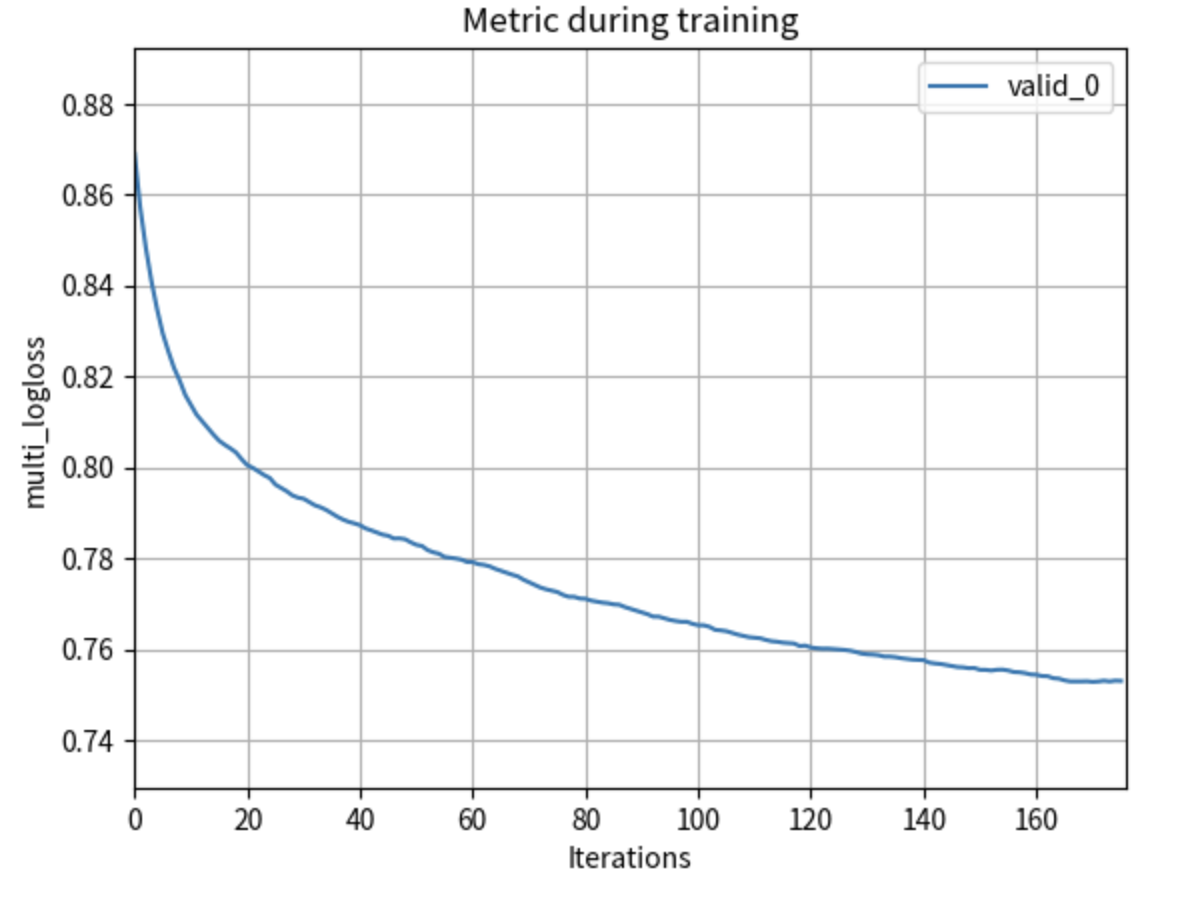

# 모델의 피처 중요도 시각화 

- 피처 중요도란?(feature importance)
    - 머신 러닝 모델에 있어서, 각 피처(독립 변수)가 최종 예측 결과에 기여하는 정도를 수치로 나타낸 것 
    - 모델이 예측을 할 때, 어떤 피처가 결과에 큰 영향을 미치는지 이해하고자 할 때 중요한 지표가 됨. 
    - 변수를 제거함으로써 모델을 단순화시키거나 더 나은 변수 선택에 대한 통찰을 얻을 수 있다. 

```python
importance_plot = lgb.plot_importance(tuning_lgbm.booster_, max_num_features=10)
#feature 중요도를 바차트로 표시, tuning_lgbm.booster_에서 제공하는 정보를 기반으로 동작. 
#booster_ 속성은 LightGBM 모델의 부스터(Booster) 객체를 포함하고 있으며, 이는 모델이 생성한 결정 트리들의 집합. 
#각 피처의 중요도는 이 결정 트리들 내에서 해당 피처가 얼마나 자주 사용되었는지를 통해 계산 됨. 
#max_num_features 매개변수를 통해 표시되는 최대 피처의 수를 제한, 가장 중요도가 높은 피처만 시각화 하도록 할 수 있음. 
plt.show()
```

## LightGBM 예측값 획득 

- 모델의 성능을 평가하는 과정에서 score 메서드를 사용하여 LightGBM 모델의 정확도를 확인할 수 있다. 
- LightGBM model은 분류 모델 ( LGBMClassifier ) 및 회귀 모델 ( LGBMRegressor )이 주로 사용된다. 
- 일반적으로 predict 메서드를 사용하여 모델이 예측값을 그대로 반환하지만, 때에 따라 모델에서 다른 형태의 출력을 필요로 할수 있다. 
    - `각 클래스별 예측 확률을 알고싶을 경우가 있음` 이럴 경우 `predict_proba`메서드를 사요하여 각 클래스 별 예측 확률을 얻을 수 있고, 이를 바탕으로 logloss점수를 계산할 수 있다. 

```python
pred = tuning_lgbm.predict(X_valid) #predict매서드는 분류 및 회귀 모델 모두에서 사용된다. 
#X_valid에 대한 예측을 수행하며, 분류 모델의 경우 가장 가능성이 높은 클래스 레이블을 반환 
#회귀 모델에서는 예측값(수치형 데이터)를 반환 
logloss_pred = tuning_lgbm.predict_proba(X_valid)
#predict_proba는 분류 문제에 사용되며, 각 클래스에 대한 예측 확률을 반환 
#반환되는 배열의 차원은 ( 예측해야할 데이터의 수, 클래스의 수 ) 이다. 

print(pred)
print('-'*40)
print(logloss_pred)
```

## XGBoost 모델과의 학습 속도 비교 

```python
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

train = pd.read_csv('당뇨_train.csv')

target_col = 'Outcome'
target = train[target_col]
train = train.drop(['ID', target_col], axis = 1)

# 2. 학습 / 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(train, target, test_size=0.2, random_state=42)



# LightGBM 모델 학습
start_lgbm = time.time()
model_lgbm_classifier = LGBMClassifier(random_state = 42) 
model_lgbm_classifier.fit(X_train, y_train) 
end_lgbm = time.time()

# XGBoost 모델 학습
start_xgb = time.time()
model_xgb_classifier = XGBClassifier(random_state = 42)
model_xgb_classifier.fit(X_train, y_train)
end_xgb = time.time()



valid_score_lgbm_classifier = model_lgbm_classifier.score(X_valid, y_valid)
valid_score_xgb_classifier = model_xgb_classifier.score(X_valid, y_valid)

print("LGBM Classifier Validation Score:", valid_score_lgbm_classifier) 
print("XGB Classifier Validation Score:", valid_score_xgb_classifier)

print("LGBM 모델의 학습 시간은", end_lgbm-start_lgbm,"초 입니다.")
print("XGB 모델의 학습 시간은", end_xgb-start_xgb,"초 입니다.")
```

```
[LightGBM] [Info] Number of positive: 182, number of negative: 339
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000056 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 600
[LightGBM] [Info] Number of data points in the train set: 521, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349328 -> initscore=-0.621993
[LightGBM] [Info] Start training from score -0.621993
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LGBM Classifier Validation Score: 0.7022900763358778
XGB Classifier Validation Score: 0.7022900763358778
LGBM 모델의 학습 시간은 0.0234377384185791 초 입니다.
XGB 모델의 학습 시간은 5.426317930221558 초 입니다.
```